<a href="https://colab.research.google.com/github/NeemaLama01/wsp/blob/main/W06_Ngima_Convolutional_Neural_Networkipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network.
## Instructions and Requirements:
This week workshop will have two sections:

*   Section: 1
  *   In this section, we will implement and observe the operations of various layers used to build the CNN.
  *   By the end of the workshop, we expect you to be able to:
      1.   Explain the Convolution operation
      2.   Explain the pooling operation
      3.   Get familiar with various hyperparameters i.e. stride, padding

*   Section: 2
  *   In this section we will compile all the learning from section 1 to build a basic Convolutional Neural Network using Keras and Tensorflow.
  

##Convolution Summary:

We convolve (slide) a small matrix also known as Filter/kernel, performing element wise matrix multiplications to produce filter-map.

  *   Objective of a convolution operations:
        1.   Apply a set of weights-a filter- to extract local features.
        2.   Use Multiple filters to extract different features.
        3.   Spatially share parameters of each filter.

Mathematically it perform following:
$$ conv(I,K)_{xy} = ∑_{i=1}^{h}\sum_{j=1}^{w}K_{ij}.I_{x+i-1,y+j-1} \tag{1} $$

Where:
- $I$ input image matrix..
-$K$ kernel/Filter used to perform convolution.

Hyper-parameters in Convolution Operations:
*   Number of Filters(K)
*   Size of Filters(F)
*   Stride(S)
*   amount of zero padding(P)

Output Dimensions is given by:

\begin{align}
\mathbf{O}  = \frac{W_{in} -f + 2p}{s} + 1 \tag{2}
\end{align}

### Exercise-1.

Perform following Convolution Operations:

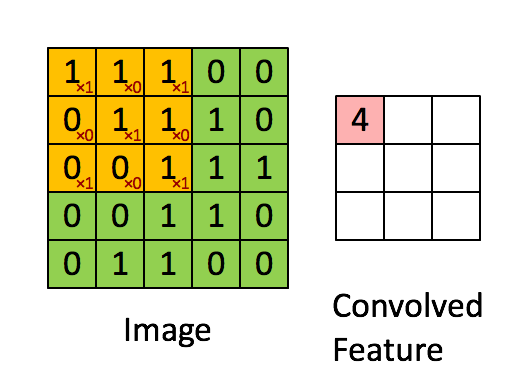

In [169]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [170]:
# Defining the input matrix as above using np.array function.
I = np.array([[1, 1, 1, 0, 0], [0, 1, 1, 1 ,0], [0, 0, 1, 1, 1,], [0, 0, 1, 1, 0], [0, 1, 1, 0, 0]])

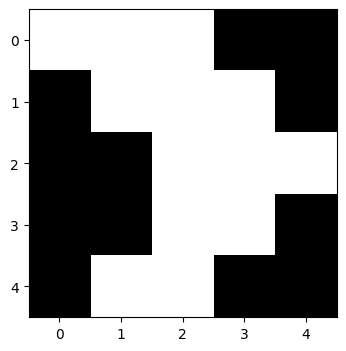

In [171]:
# Visualizing the input.
plt.imshow(I)

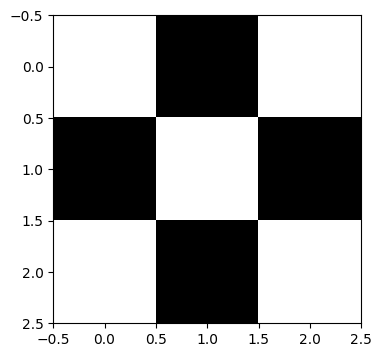

In [172]:
# Defining the input matrix as above using np.matrix function.
K = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]])
# Visualizing the Filter.
plt.imshow(K)


In [173]:
import numpy as np

def convolution(img, filter):
    """
    Function performs convolution operations.

    Arguments:
    img (ndarray): numpy array of an input image (2D matrix)
    filter (ndarray): numpy array of an input filter (2D matrix)

    Returns:
    ndarray: Filter map (feature map) of dimensions determined by the convolution operation
    """
    # Calculate output dimensions
    img_height, img_width = img.shape
    filter_height, filter_width = filter.shape

    # Output dimension calculation (using the standard convolution formula)
    output_height = img_height - filter_height + 1
    output_width = img_width - filter_width + 1

    # Initialize the output feature map
    filter_map = np.zeros((output_height, output_width))

    # Perform the convolution operation
    for i in range(output_height):
        for j in range(output_width):
            # Extract the current window from the image
            window = img[i:i+filter_height, j:j+filter_width]

            # Perform element-wise multiplication and sum
            filter_map[i, j] = np.sum(window * filter)

    return filter_map

In [174]:
img = convolution(I, K)

In [175]:
assert img.shape == (3, 3), " Convolution Operation did not produce correct output"

Test Passed


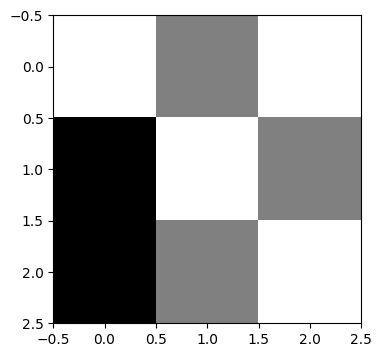

In [176]:
plt.imshow(img)
print("Test Passed")

# Section-2: In this section we will build very basic CNN architecture, Compile and train our CNN model.

This will be further divided into following sections:


## Section-2.1: Data Pre-processing.

Expected structure of folder:

-/Datasets/

      --train/
        -- acai/....     
        -- cupuacu/---
        -- all the classes--

In [ ]:
data_dir = "/content/drive/MyDrive/1. Workshops/Workshops(L5 and L6)/Workshop-6/Week-6/FruitinAmazon/train"

In [42]:
import zipfile
with zipfile.ZipFile('/content/Copy of FruitinAmazon.zip','r') as zip_ref:
  zip_ref.extractall('/content')

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [44]:
# Hyper-parameters:
batch_size = 32
img_height = 180
img_width = 180

### Load the Data:

We will use tf.keras.utility to load the image, for this function to work, your data should be in the structure suggested above.

We will do this for both training and validation dataset.

### Exercise:

1. To train a deep learning model we need to create a data pipeline, Multiple different approaches are available within keras framework;
one such framework is
  "tf.keras.utils.image_dataset_from_directory("parameter")

Implement above framework and explain the parameters you have used in the comment.

In [47]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/FruitinAmazon/train",
     validation_split=0.2,
      subset="training",
      seed=1337,
      image_size=(img_height, img_width),
      batch_size=batch_size
  )

Found 90 files belonging to 6 classes.
Using 72 files for training.


**Parameters used:**
 validation_split: Fraction of data to reserve for validation (here, 20%)

 subset: specify which portion to use ("training" or "validation").

 seed: Random seed for shuffling and splitting the data.

 image_size: sizes all images to this fixed dimension

 batch_size:Number of samples per batch.


In [48]:
val_ds = tf.keras.utils.image_dataset_from_directory(
        "/content/FruitinAmazon/train",
        validation_split=0.2,
        subset="validation",
        seed=1337,
        image_size=(img_height, img_width),
        batch_size=batch_size
  )

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [134]:
# Printing out number of Classes
class_names = train_ds.class_names
print(class_names)

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


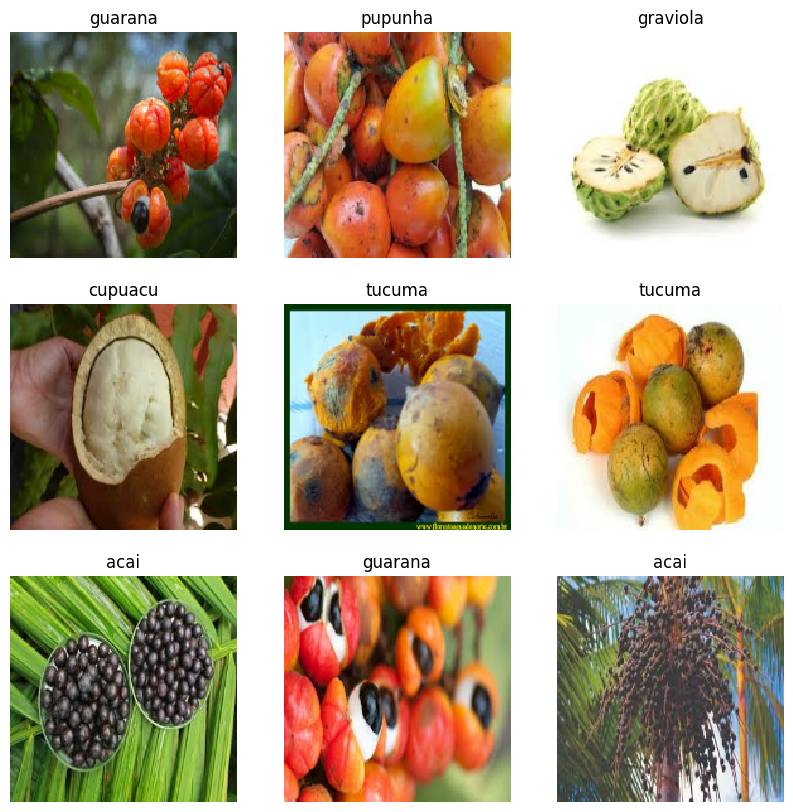

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [136]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


## Design CNN Architecture:

For this task, we will build a CNN with following layers:

Feature-Extraction and Convolution Operations.
1.   Convolutional Layer [F=(3,3),K=16,P="same",S=1]-> Activation["ReLU"].
2.   Pooling layer[max, F=(2,2), S=2].
3.   Convolutional Layer [F=(3,3),K=16,P="same",S=1]-> Activation["ReLU"].
4.   Pooling layer[max, F=(2,2), S=2].

Classification-Assigning a class probabilities to each classes.
1.   Flatten Layer()
2.   Hidden/Dense Layer [number of neurons=128].
3.   Output Layer [number of neurons=num_classes].


### Exercise:

Please fill the hyper-parameters as defined above in the below layers.

In [137]:
def generate_model(image_height, image_width, nchannels, num_classes):
  """
  This function will generate a model with set of hyperparameters defined above.
  Input Args:
  image_height[int] = Height of an image.
  image_width[int] = Width of an image.
  nchannels[int] = Number of channels in image.
  num_classes[int] = Number of classes in dataset.
  Output Args:
  model-> A CNN model.
  """
  model = tf.keras.Sequential([
      # Rescaling and input layer, [For keras the input shape must be(image height, image width, channels)]
      layers.Rescaling(1./255, input_shape=(image_height,image_width,nchannels)),
      # First Block of Convolution and Pooling Operations.
      layers.Conv2D(16, kernel_size=(3,3),strides=1,padding="same",activation="relu"),
      layers.MaxPooling2D(pool_size=(2, 2),strides=2),
      # Second Block of Convolution and Pooling Operations.
      layers.Conv2D(16, kernel_size=(3,3),strides=1,padding="same",activation="relu"),
      layers.MaxPooling2D(pool_size=(2, 2),strides=2),
      # Fully connected classifier.
      layers.Flatten(),
      layers.Dense(128,activation="relu"),
      layers.Dense(128,activation="softmax")
  ])
  return model

img_height = 180
img_width = 180

In [138]:
num_classes = len(class_names)
model = generate_model(180, 180, 3, num_classes)

In [139]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 90, 90, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 45, 45, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 32400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       4,147,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          16,512 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,166,608 (15.89 MB)

 Trainable params: 4,166,608 (15.89 MB)

 Non-trainable params: 0 (0.00 B)

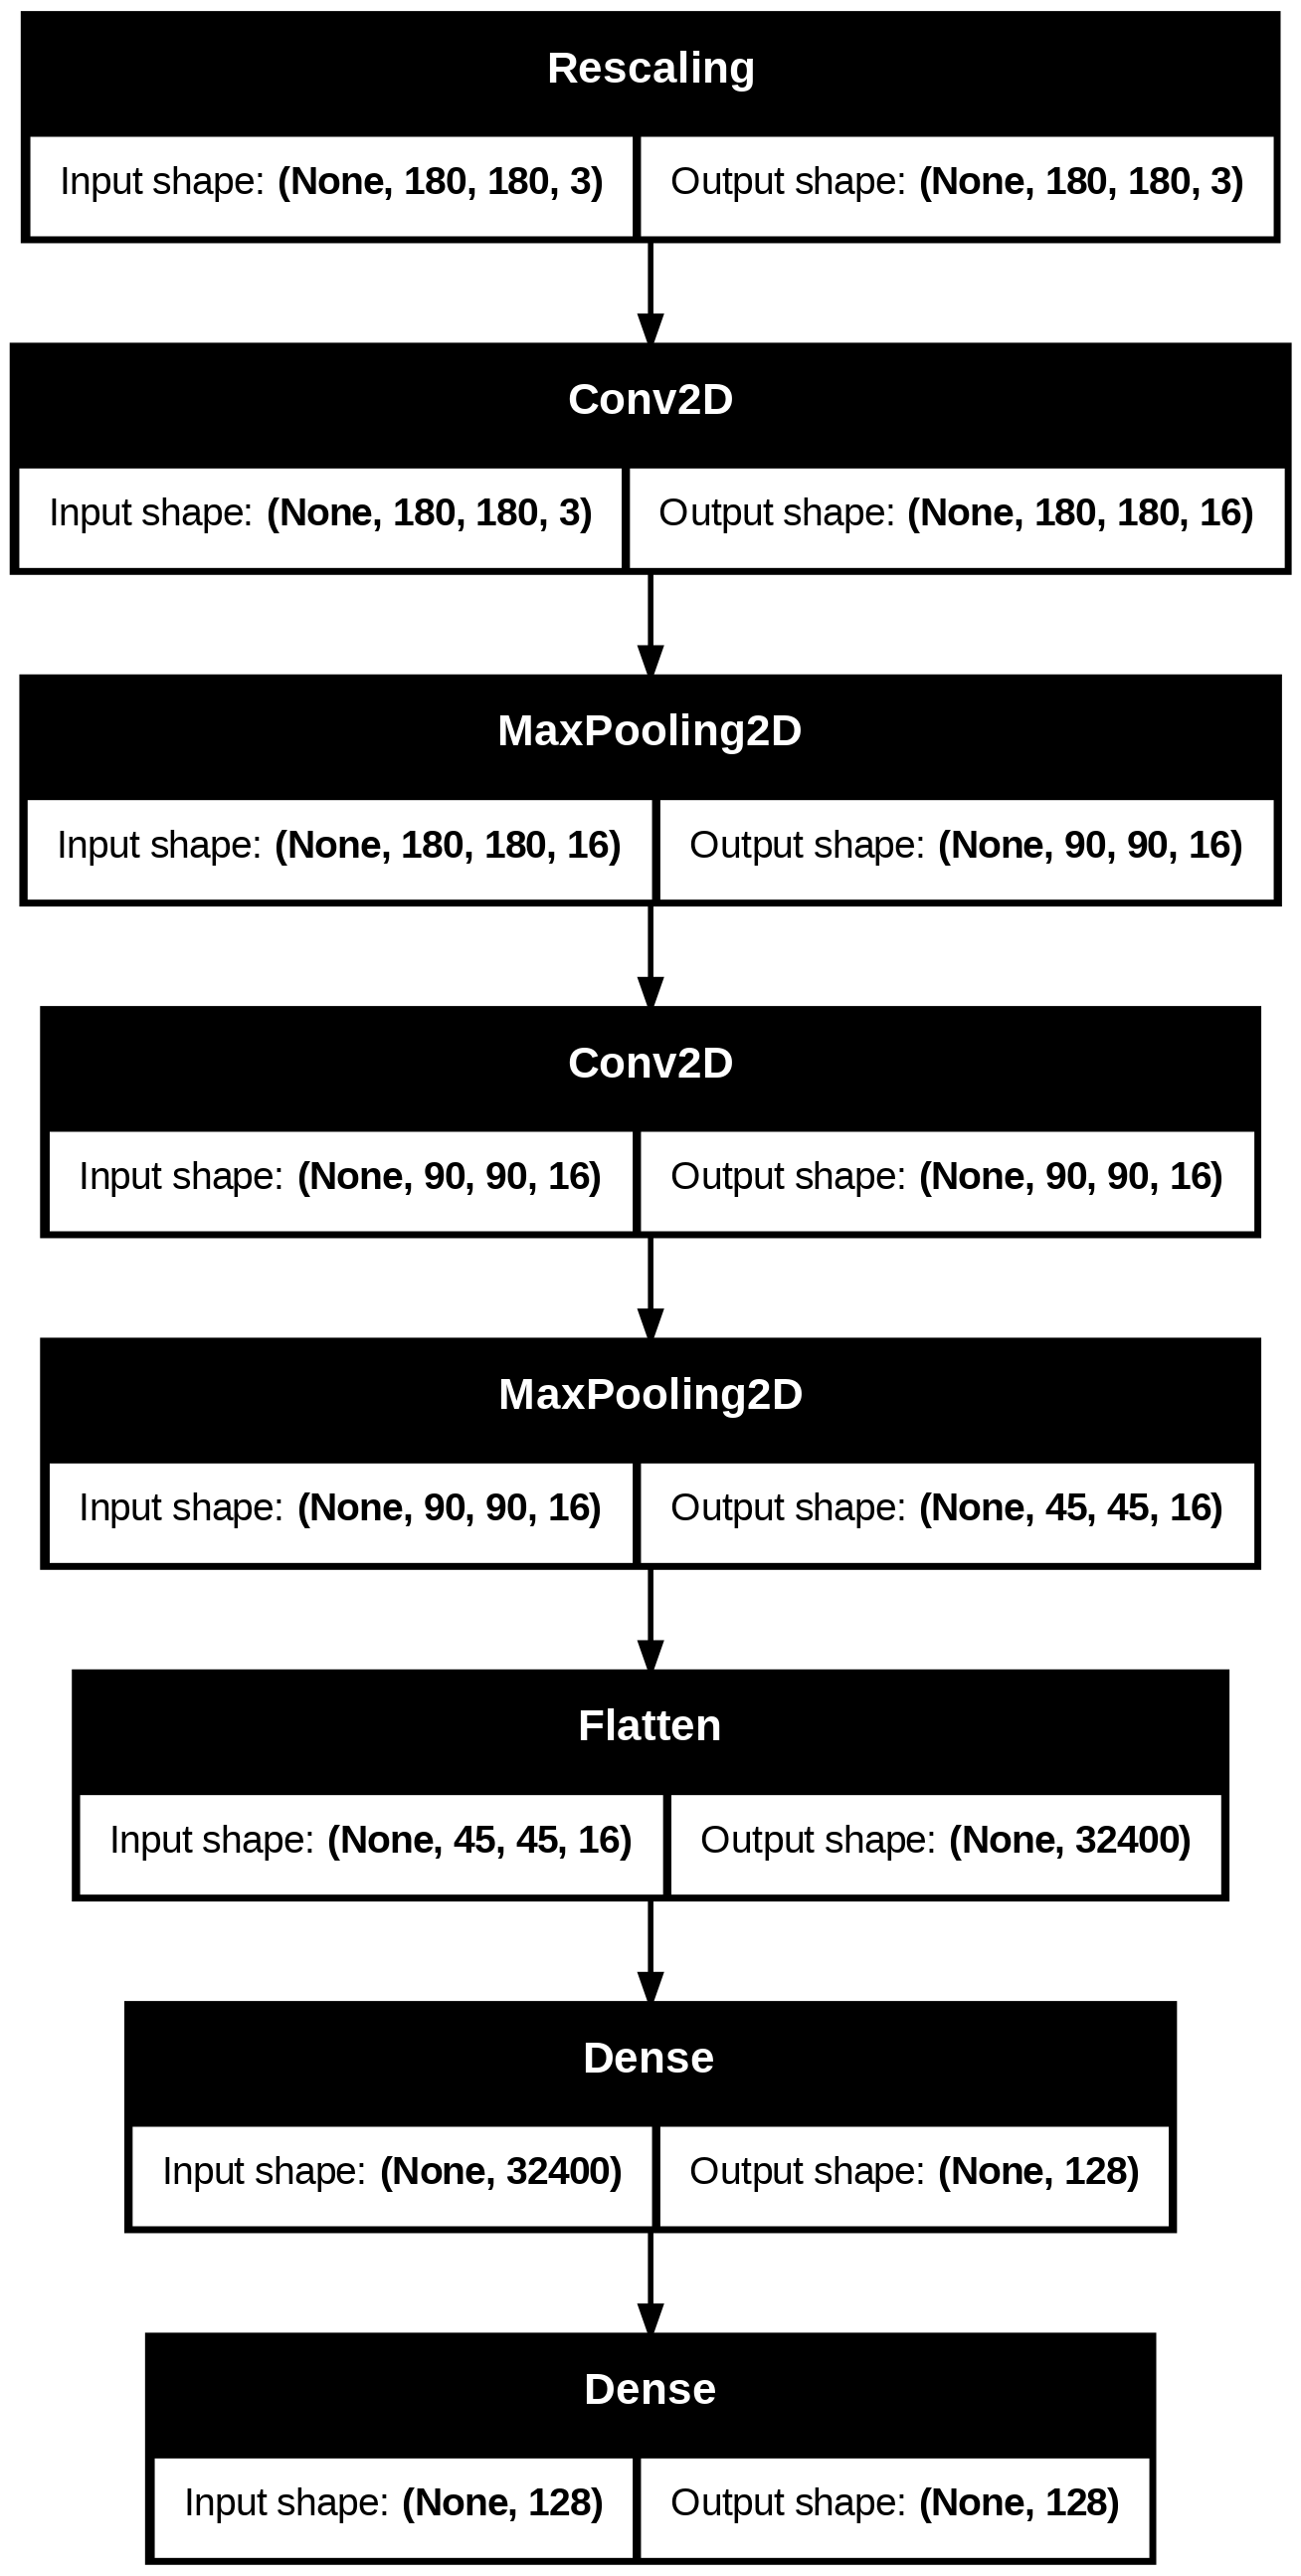

In [140]:
keras.utils.plot_model(model, show_shapes=True)

## Compile and Train Model.

Once we built the model, we need to compile the model before we start training.

In Model compilation, we do the following:
*   Checks for format Error.
*   Defines the loss function.
*   Defines the optimizer.
*   Defines the learning rate.
*   Defines the metrics we will be using.

For training our model we will be using:
*   loss --> SparseCategoricalCrossEntropy.
*   Optimizer --> Adam.
*   Evaluation Metric --> Accuracy.


In [141]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

### Train the Model.

For training a model with all the given hyper-parameters, and argumets we invoke fit methods.

It is a standard practise to return and hold record of losses values and metric values during training in variablel-history.

In [142]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.0440 - loss: 4.4916

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 576ms/step - accuracy: 0.0503 - loss: 4.4559 - val_accuracy: 0.0556 - val_loss: 2.9105
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 630ms/step - accuracy: 0.2964 - loss: 2.4137 - val_accuracy: 0.1667 - val_loss: 1.9751
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 742ms/step - accuracy: 0.3997 - loss: 1.6832 - val_accuracy: 0.2778 - val_loss: 1.7736
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.5148 - loss: 1.2047 - val_accuracy: 0.3333 - val_loss: 1.6364
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.7995 - loss: 0.8628 - val_accuracy: 0.3333 - val_loss: 1.4587
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 0.7865 - loss: 0.6978 - val_accuracy: 0.4444 - val_loss: 1.4746
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 0.8229 - loss: 0.4795 - val_accuracy: 0.4444 - val_loss: 1.5199
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 513ms/step - accuracy: 0.9006 - loss: 0.3432 - val_accuracy: 0.3889 - val_loss: 1.6172
Epo

## Observe the Model Performance.


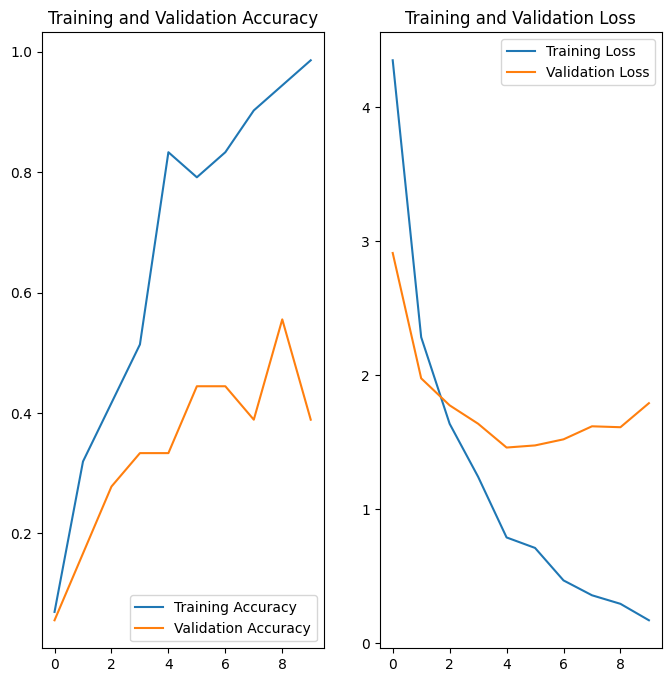

In [143]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Home Task:

Create a Test Set and Perform a model evaluation to find the test accuracy.

Based on last week built a function which predicts input examples, and also plot the result.


In [144]:
# Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/FruitinAmazon/test",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [146]:
model.save('fruit_classification_model.keras')

In [147]:
loaded_model=tf.keras.models.load_model('/content/fruit_classification_model.keras')

In [148]:
print(loaded_model.summary())


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 90, 90, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 45, 45, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 32400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       4,147,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          16,512 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,499,826 (47.68 MB)

 Trainable params: 4,166,608 (15.89 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,333,218 (31.79 MB)

None


In [149]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.4333 - loss: 1.4079
Test Accuracy: 0.4333333373069763


In [150]:
x_test, y_test = split_dataset(test_ds)

# Evaluate the model on the test set
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


Batch images shape: (30, 180, 180, 3)
Batch labels shape: (30,)
x_test shape: (30, 180, 180, 3)
y_test shape: (30,)
1/1 - 1s - 1s/step - accuracy: 0.4333 - loss: 1.4079
Test Loss: 1.4078584909439087
Test Accuracy: 0.4333333373069763


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


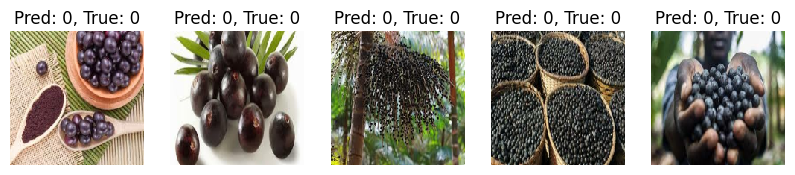

In [159]:
import matplotlib.pyplot as plt
import numpy as np

def predict_and_plot(model, test_ds, num_examples=5):
    # Retrieve a batch of images and labels from the test dataset
    images, labels = next(iter(test_ds))

    # Make predictions using the model
    predictions = model.predict(images)

    # Plot the images with their predictions and true labels
    plt.figure(figsize=(10, 10))

    for i in range(num_examples):
        ax = plt.subplot(1, num_examples, i + 1)
        ax.imshow(images[i].numpy().astype("uint8"))
        predicted_label = np.argmax(predictions[i])  # Predicted class (highest probability)
        true_label = labels[i].numpy()  # True class label

        ax.set_title(f"Pred: {predicted_label}, True: {true_label}")
        ax.axis("off")

    plt.show()
predict_and_plot(loaded_model,test_ds)